# PósTech FIAP - IA para Devs (Turma 9IADT)
## Tech Challenge - Fase 1
**Sistema de suporte ao diagnóstico médico do cancêr de mama**

---

| Aluno | RM |
|--------|------------------|
| Antonio Bazo | 372646 |
| Renato Mattos | 370975 |
| Vinicius Geisler | 373670 |
| Marcelo Costa |  |
| Vinicius Blasque | 370746 |

---

**Objetivo:** Construir um modelo de analise de dados de exames para classificação de tumores como benignos ou malignos, servindo como ferramenta de apoio ao diagnóstico

**Dataset principal:** [Breast Cancer Wisconsin](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data)

---


## 1. Setup e Dependências

Configuração do workspace e carregamento das bibliotecas necessárias para análise exploratória, engenharia de atributos e treinamento dos modelos de classificação.

In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro

# Machine Learning - Engenharia e Modelagem
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# Algoritmos e Métricas
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Ambiente configurado.")

Ambiente configurado.


## 2. Ingestão e Carregamento dos Dados

Leitura da base de dados original e carregamento em DataFrame para inspeção inicial da estrutura, dimensões e integridade das informações.

In [142]:
# Carregamento do dataset
dataset = pd.read_csv("data/breast-cancer-wisconsin-diagnostic-data-set.csv")

# Exibição das dimensões do dataset
print(f"Dataset carregado com sucesso: {dataset.shape[0]} instâncias e {dataset.shape[1]} atributos.")

# Visualização das 5 primeiras linhas
dataset.head()

Dataset carregado com sucesso: 569 instâncias e 33 atributos.


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## 3. Limpeza e Transformação Inicial dos Dados

Eliminação de atributos irrelevantes (identificadores e resíduos de carga) e mapeamento da variável alvo para terminologia clínica. O objetivo é garantir a integridade do conjunto de dados e a legibilidade das análises subsequentes.

In [143]:
# Remoção de colunas desnecessárias
dataset.drop(['Unnamed: 32', 'id'], axis=1, inplace=True)

# Mapeamento de rótulos para suporte à interpretação clínica
dataset['diagnosis'] = dataset['diagnosis'].map({'M': 'Maligno', 'B': 'Benigno'})

# Validações e Prova de Sanidade
print("--- RELATÓRIO DE LIMPEZA ---")
print(f"Valores nulos restantes: {dataset.isnull().sum().sum()}")
print(f"Novas dimensões (Linhas, Colunas): {dataset.shape}\n")

print("Distribuição da variável alvo:")
print(dataset['diagnosis'].value_counts())
print("\n" + "-"*30 + "\n")

# O info() exibe um resumo técnico detalhado dos tipos de dados
dataset.info()

--- RELATÓRIO DE LIMPEZA ---
Valores nulos restantes: 0
Novas dimensões (Linhas, Colunas): (569, 31)

Distribuição da variável alvo:
diagnosis
Benigno    357
Maligno    212
Name: count, dtype: int64

------------------------------

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    str    
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mea

## 4. Resumo Estatístico dos Dados

Extração de métricas centrais e de dispersão (média, desvio padrão, quartis e amplitudes) das características dos tumores. A visualização transposta facilita a inspeção rápida de escalas, permitindo identificar a variação de magnitude entre os atributos.

In [144]:
# Geração de estatísticas descritivas com transposição para melhor legibilidade (Linhas viram colunas e vice-versa)
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## 5. Análise de Outliers (Pontos Fora da Curva)

Aplicação do método IQR (Interquartile Range) para identificação de valores atípicos nas dimensões dos tumores. Esta análise é essencial para quantificar o volume de dados extremos que podem impactar a variância global e influenciar o comportamento dos algoritmos sensíveis a escalas.

In [145]:
# Selecionamos apenas as colunas de números para o cálculo
colunas_numericas = dataset.select_dtypes(include=['float64'])

# Cálculo do Intervalo Interquartil (IQR)
Q1 = colunas_numericas.quantile(0.25)
Q3 = colunas_numericas.quantile(0.75)
IQR = Q3 - Q1

# Definindo os limites (o padrão é 1.5)
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Contando quantos outliers existem em cada coluna
outliers = ((colunas_numericas < limite_inferior) | (colunas_numericas > limite_superior)).sum()

print("Resumo de Outliers encontrados por coluna:")
print(outliers[outliers > 0].sort_values(ascending=False))

Resumo de Outliers encontrados por coluna:
area_se                    65
radius_se                  38
perimeter_se               38
area_worst                 35
smoothness_se              30
compactness_se             28
fractal_dimension_se       28
symmetry_se                27
area_mean                  25
fractal_dimension_worst    24
symmetry_worst             23
concavity_se               22
texture_se                 20
concave points_se          19
concavity_mean             18
radius_worst               17
compactness_worst          16
compactness_mean           16
perimeter_worst            15
symmetry_mean              15
fractal_dimension_mean     15
radius_mean                14
perimeter_mean             13
concavity_worst            12
concave points_mean        10
smoothness_worst            7
texture_mean                7
smoothness_mean             6
texture_worst               5
dtype: int64


**Decisão Técnica: Retenção de Outliers**
A detecção de valores atípicos (ex: 65 registros em area_se) **não resultará na exclusão** manual desses dados. No domínio da oncologia, extremos estatísticos frequentemente representam a variabilidade biológica de tumores mais agressivos ou casos críticos.

Como o objetivo do modelo é priorizar o Recall (Sensibilidade), a manutenção desses registros é estratégica. O algoritmo deve ser capaz de aprender padrões de variabilidade extrema para minimizar falhas de diagnóstico (falsos negativos), garantindo maior segurança clínica na identificação de casos malignos.

Por isso decidimos **não removê-los**.


### Análise Exploratória Visual (EDA)

Avaliação da distribuição das classes para verificação de balanceamento do dataset e análise de densidade de atributos-chave. O objetivo é identificar padrões de separação e o nível de sobreposição entre diagnósticos benignos e malignos em variáveis críticas.

C:\Users\anton\AppData\Local\Temp\ipykernel_2828\3367506580.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataset, x='diagnosis', palette={'Maligno': '#ef476f', 'Benigno': '#118ab2'})


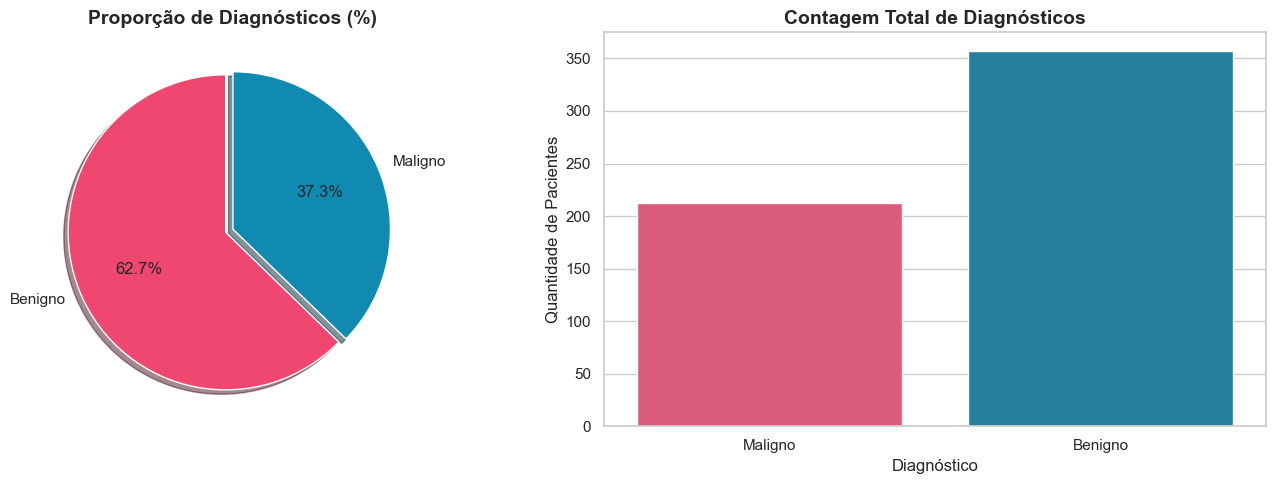

In [146]:


# Configuração visual elegante
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(14, 5))

# GRÁFICO REDONDO (mostra a Porcentagem)
plt.subplot(1, 2, 1)
contagem = dataset['diagnosis'].value_counts()
plt.pie(contagem, labels=contagem.index, autopct='%1.1f%%', startangle=90, 
        colors=['#ef476f', '#118ab2'], explode=(0.05, 0), shadow=True)
plt.title('Proporção de Diagnósticos (%)', fontsize=14, fontweight='bold')

# GRÁFICO BARRAS (mostra a Quantidade Absoluta)
plt.subplot(1, 2, 2)
sns.countplot(data=dataset, x='diagnosis', palette={'Maligno': '#ef476f', 'Benigno': '#118ab2'})
plt.title('Contagem Total de Diagnósticos', fontsize=14, fontweight='bold')
plt.xlabel('Diagnóstico')
plt.ylabel('Quantidade de Pacientes')

plt.tight_layout()
plt.show()

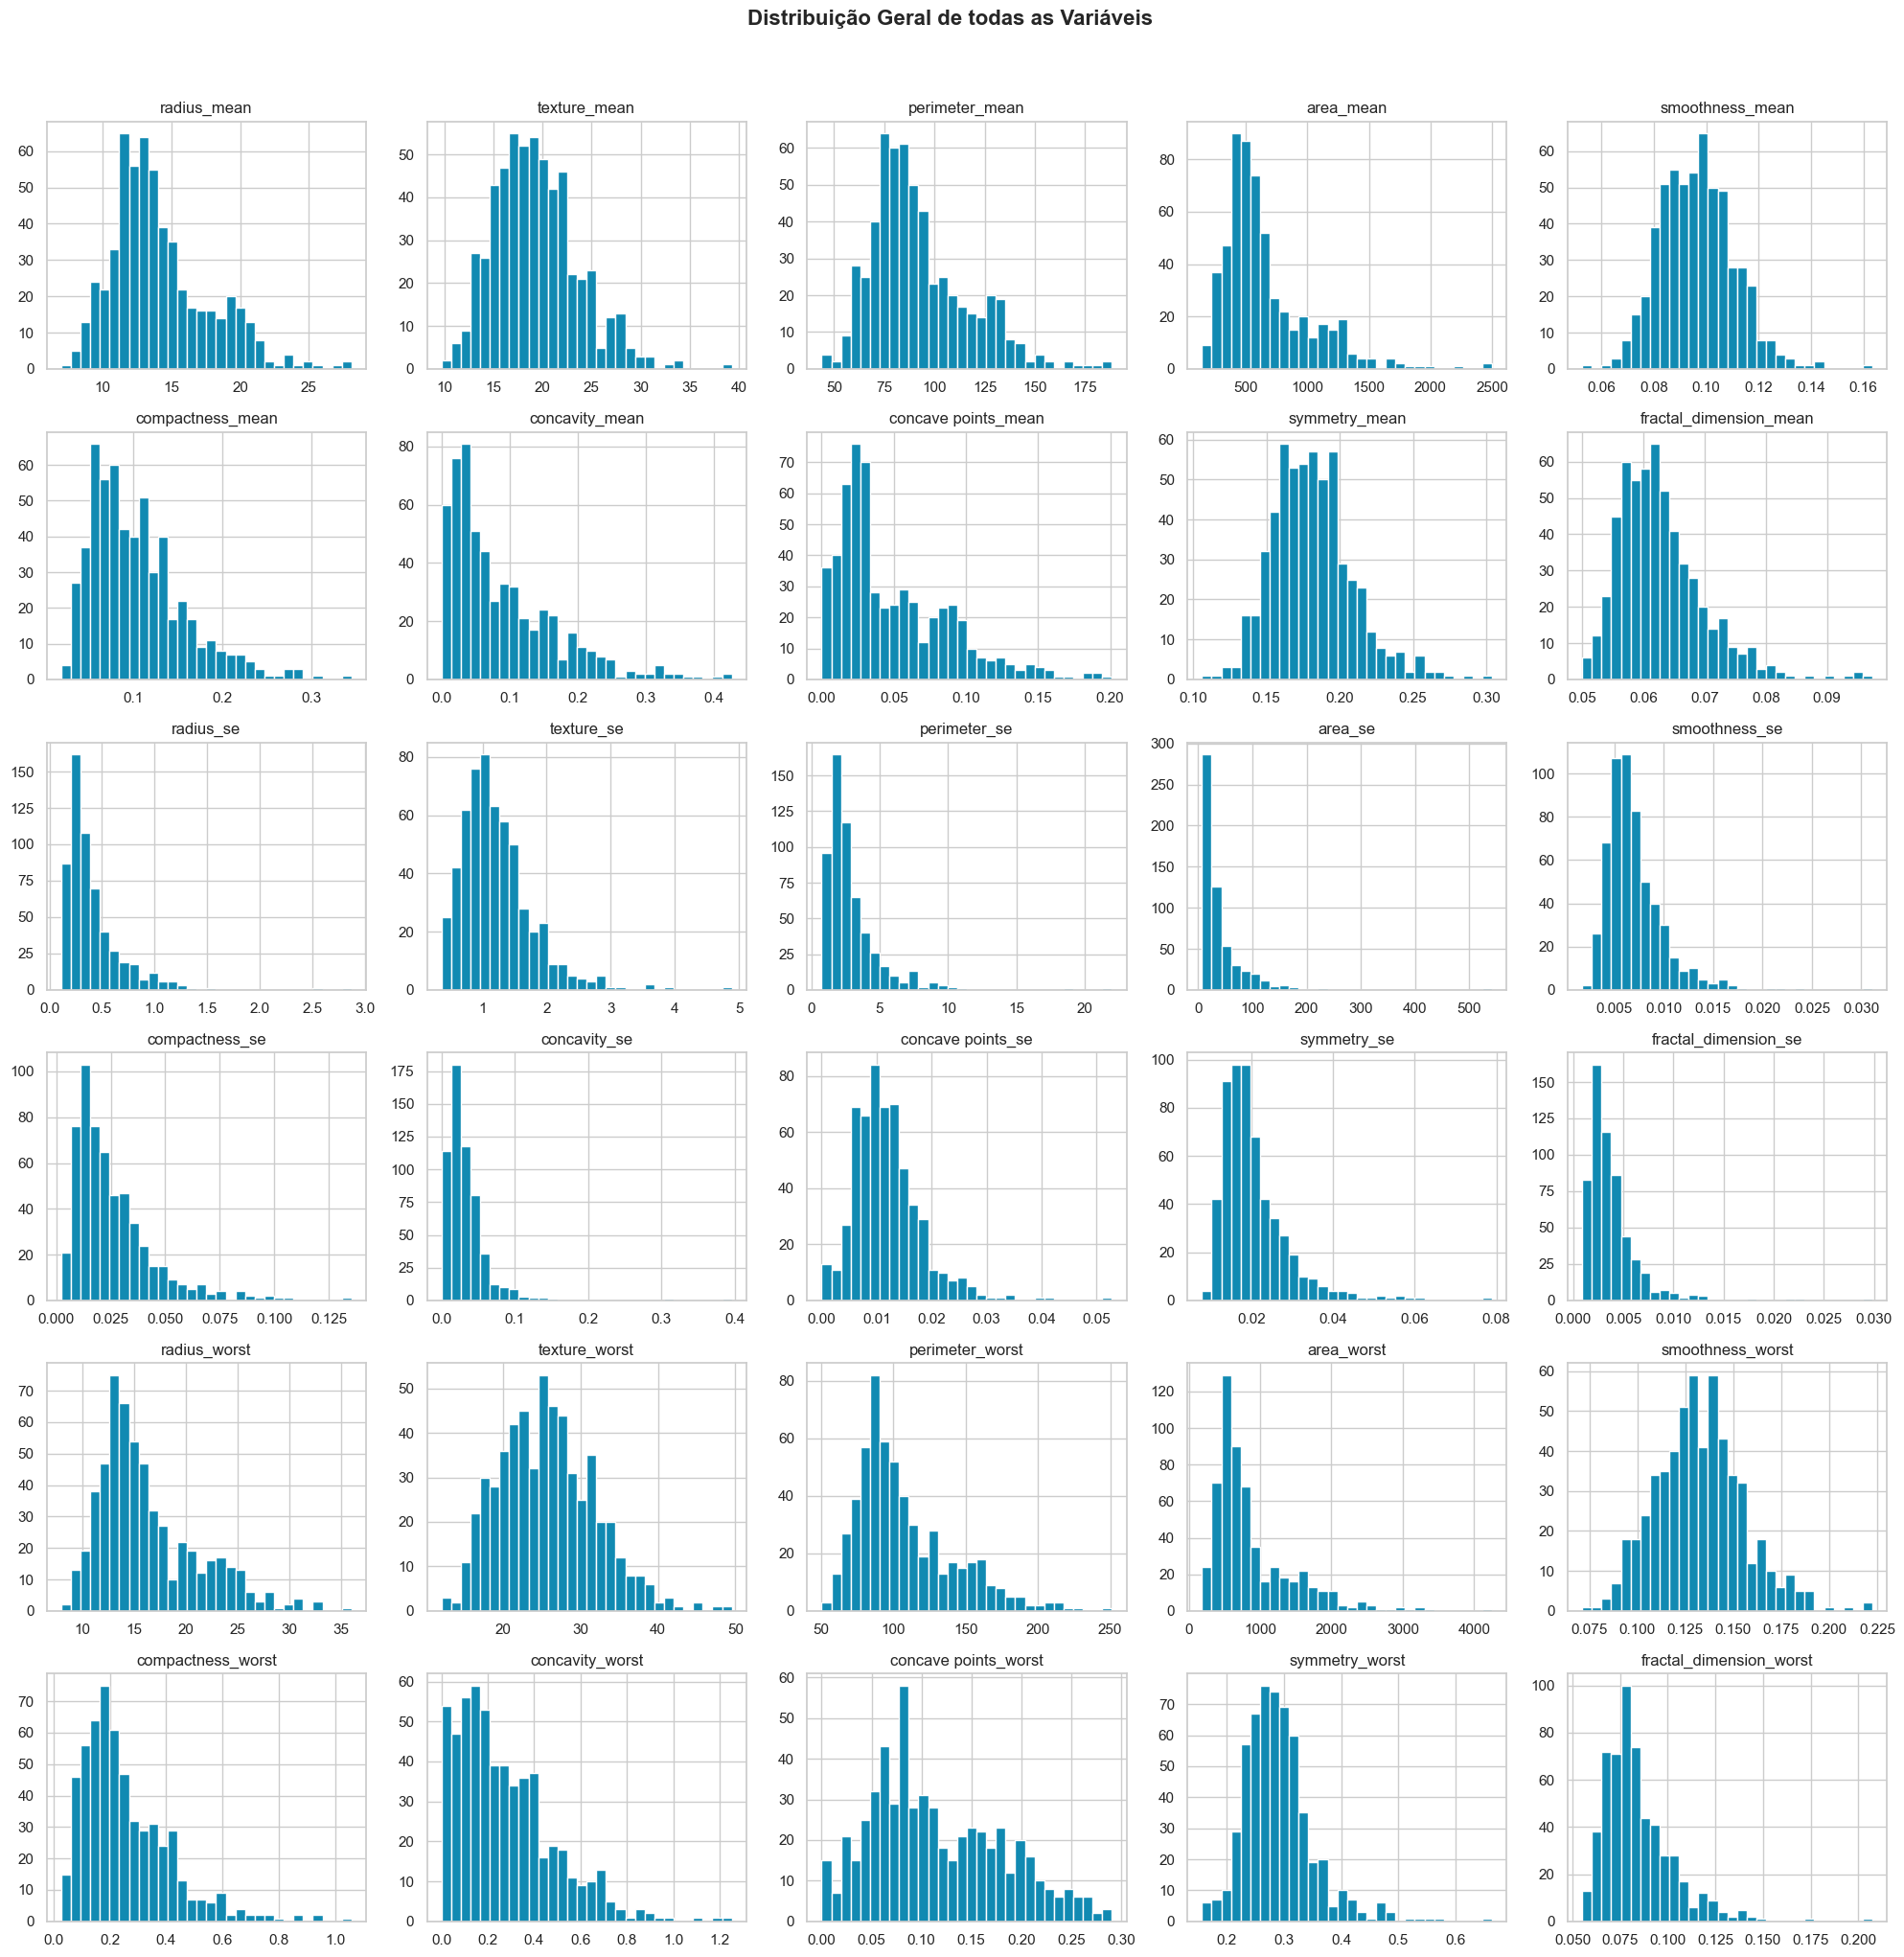

In [147]:
# Histograma de todas as variáveis para visão geral
dataset.hist(bins=30, figsize=(20, 20), color='#118ab2', edgecolor='white')
plt.suptitle('Distribuição Geral de todas as Variáveis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Particionamento entre Treino e Teste

Segregação do conjunto de dados em subconjuntos de treinamento e teste para validação da capacidade de generalização. O particionamento é essencial para garantir que a performance final seja mensurada em dados não observados durante o ajuste do modelo, mitigando riscos de overfitting.

In [148]:
# Separação de Features (X) e Target (y)
X = dataset.drop(columns=['diagnosis'])
y = dataset['diagnosis']

# Divisão dos dados (80/20)
# Usamos o random_state=42 para garantir que o resultado seja sempre o mesmo ao rodar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verificação das dimensões
print("Separação concluída com sucesso:")
print(f"Amostras de Treino: {X_train.shape[0]} registros")
print(f"Amostras de Teste: {X_test.shape[0]} registros")
print(f"Total de atributos (Features): {X_train.shape[1]}")

Separação concluída com sucesso:
Amostras de Treino: 455 registros
Amostras de Teste: 114 registros
Total de atributos (Features): 30


## 7. Padronização de Atributos (Feature Scaling)

Considerando a disparidade de escalas entre as variáveis (identificada na análise descritiva) e a sensibilidade do PCA e dos classificadores a essas magnitudes, aplicamos a padronização via StandardScaler.

**Critério Técnico:** O ajuste (fit) é realizado exclusivamente no conjunto de treinamento para mitigar o risco de Data Leakage (vazamento de dados), assegurando que informações do teste não influenciem os parâmetros da escala.

A feature diagnosis possui apenas dois valores possiveis (B e M), send B = Benigno e M = Maligno.
A distribuição entre os valores esta aproximadamente 60% B e 40% M.

In [149]:
# Instanciamos o "padronizador"
scaler = StandardScaler()

# Ajuste e transformação do treino; apenas transformação do teste
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Conversão para DataFrame para preservação dos nomes das colunas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

# Verificação visual
X_train_scaled.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,-1.440753,-0.435319,-1.362085,-1.139118,0.780573,0.718921,2.823135,-0.119150,1.092662,2.458173,...,-1.232861,-0.476309,-1.247920,-0.973968,0.722894,1.186732,4.672828,0.932012,2.097242,1.886450
1,1.974096,1.733026,2.091672,1.851973,1.319843,3.426275,2.013112,2.665032,2.127004,1.558396,...,2.173314,1.311279,2.081617,2.137405,0.761928,3.265601,1.928621,2.698947,1.891161,2.497838
2,-1.399982,-1.249622,-1.345209,-1.109785,-1.332645,-0.307355,-0.365558,-0.696502,1.930333,0.954379,...,-1.295284,-1.040811,-1.245220,-0.999715,-1.438693,-0.548564,-0.644911,-0.970239,0.597602,0.057894
3,-0.981797,1.416222,-0.982587,-0.866944,0.059390,-0.596788,-0.820203,-0.845115,0.313264,0.074041,...,-0.829197,1.593530,-0.873572,-0.742947,0.796624,-0.729392,-0.774950,-0.809483,0.798928,-0.134497
4,-1.117700,-1.010259,-1.125002,-0.965942,1.269511,-0.439002,-0.983341,-0.930600,3.394436,0.950213,...,-1.085129,-1.334616,-1.117138,-0.896549,-0.174876,-0.995079,-1.209146,-1.354582,1.033544,-0.205732


## 8. Análise de Multicolinearidade (Matriz de Correlação)

Cálculo da matriz de correlação aplicado ao conjunto de treinamento para identificação de redundâncias entre os atributos. Este diagnóstico fornece o subsídio estatístico para a aplicação do PCA, permitindo simplificar o espaço de características ao mitigar a multicolinearidade sem comprometer a variância explicada.

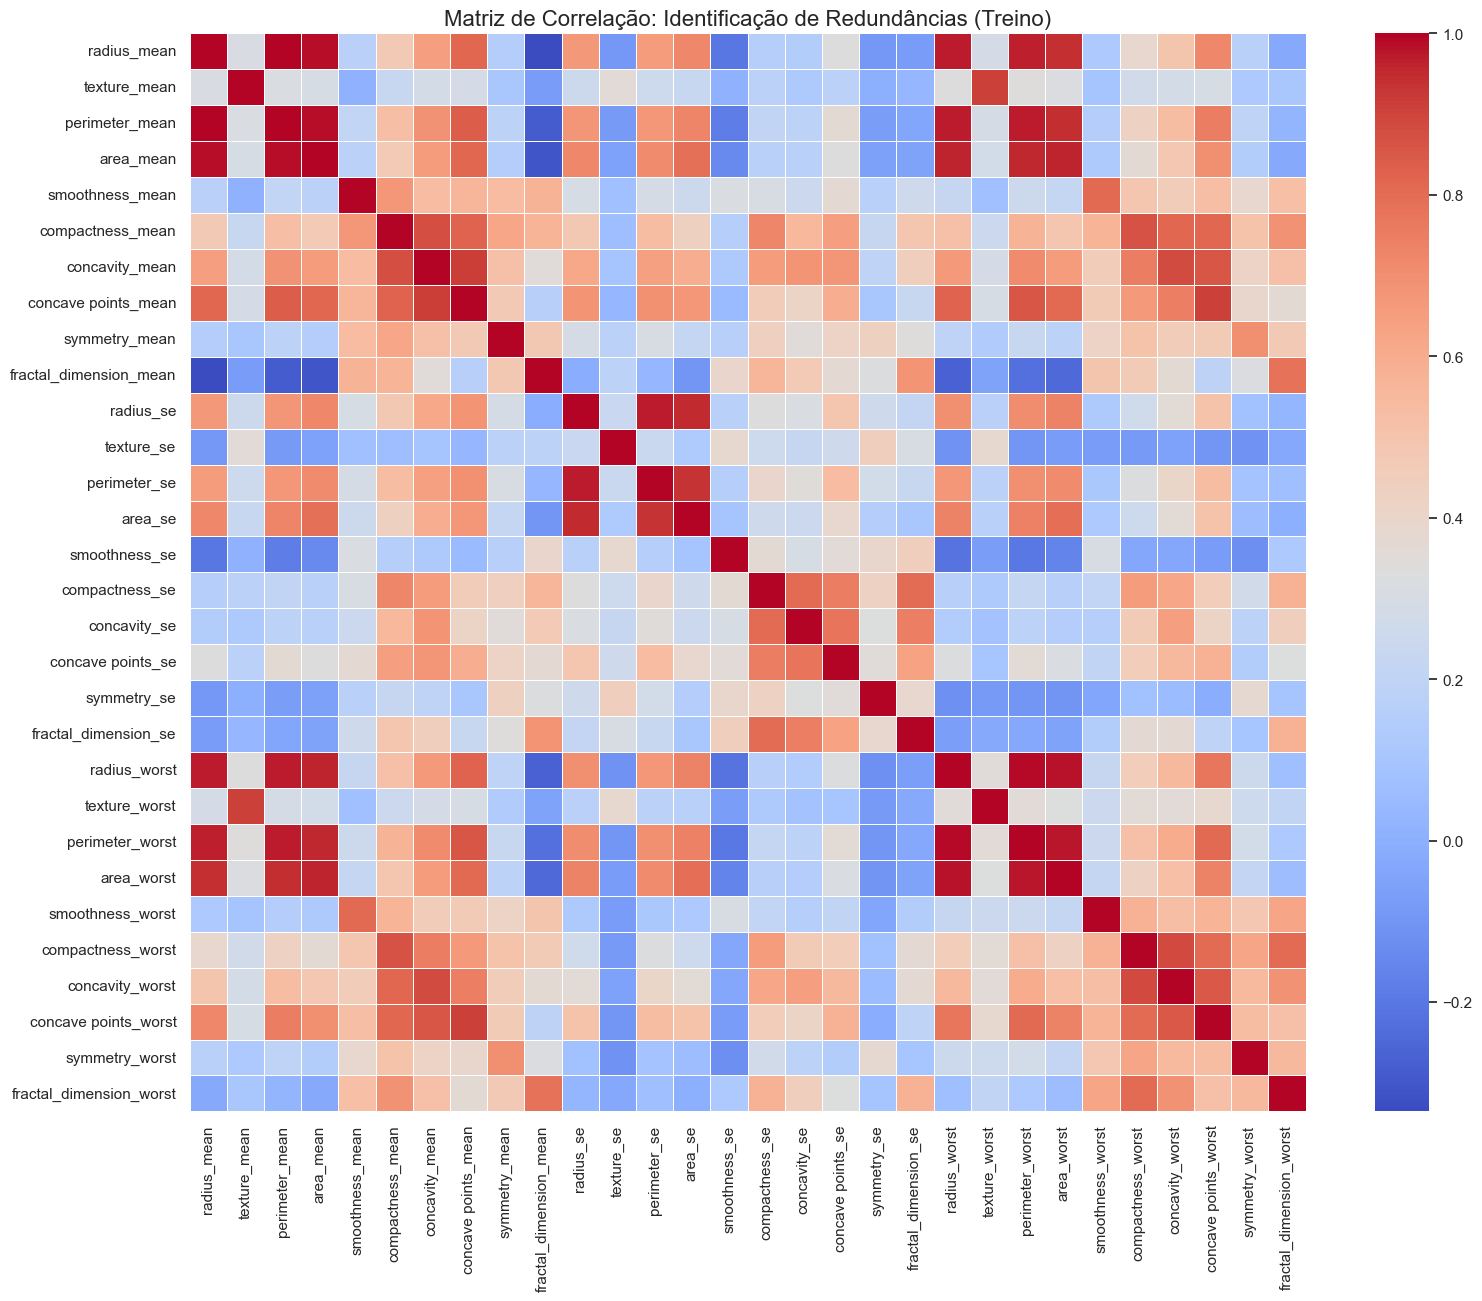

In [150]:
# Cálculo da matriz de correlação (Pearson)
matriz_correlacao = X_train_scaled.corr()

# Configuração da visualização via Mapa de Calor (Heatmap)
plt.figure(figsize=(18, 14))

# Visualização das correlações: tons de vermelho indicam alta colinearidade
sns.heatmap(matriz_correlacao, annot=False, cmap='coolwarm', linewidths=0.5)

plt.title('Matriz de Correlação: Identificação de Redundâncias (Treino)', fontsize=16)
plt.show()

## 9. Redução de Dimensionalidade (PCA)

Aplicação de Principal Component Analysis (PCA) para compressão do espaço de características, visando mitigar a redundância identificada na análise de colinearidade. O objetivo é reduzir a complexidade dimensional e o custo computacional do modelo, retendo 95% da variância total do conjunto de dados original.

--- RELATÓRIO DO PCA ---
Colunas originais: 30
Colunas após PCA: 10
Informação preservada: 95.11%



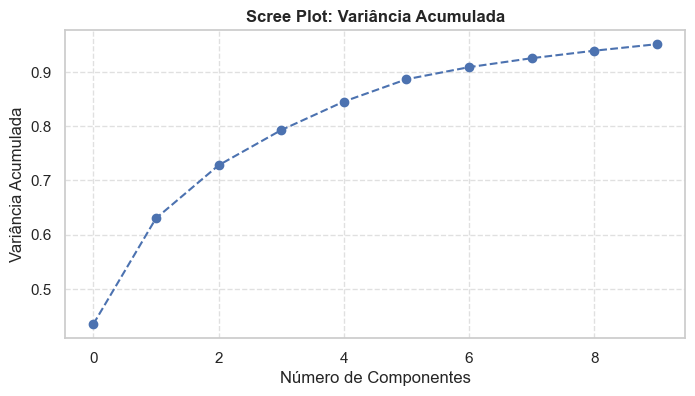

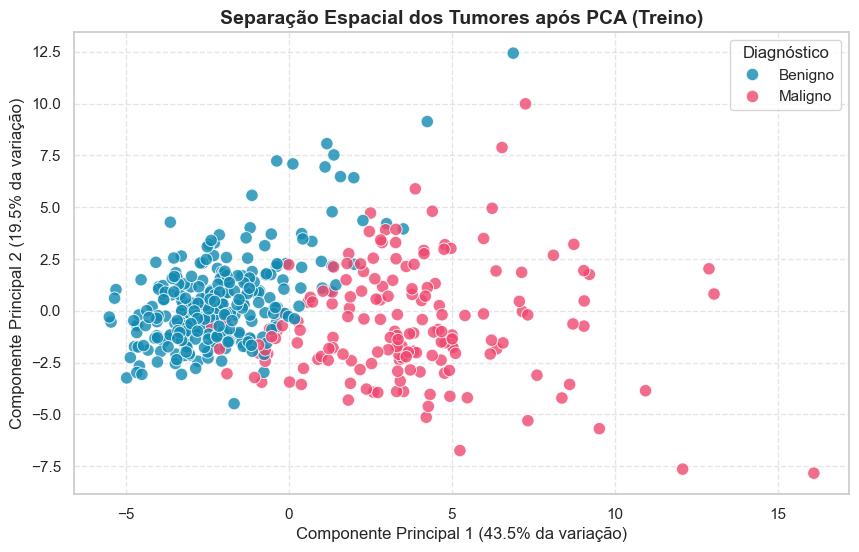

--- ANÁLISE DE NORMALIDADE (SHAPIRO-WILK) ---
PC1: p-value = 0.0000 -> Não apresenta Normalidade
PC2: p-value = 0.0000 -> Não apresenta Normalidade
PC3: p-value = 0.0000 -> Não apresenta Normalidade
PC4: p-value = 0.0000 -> Não apresenta Normalidade
PC5: p-value = 0.0000 -> Não apresenta Normalidade


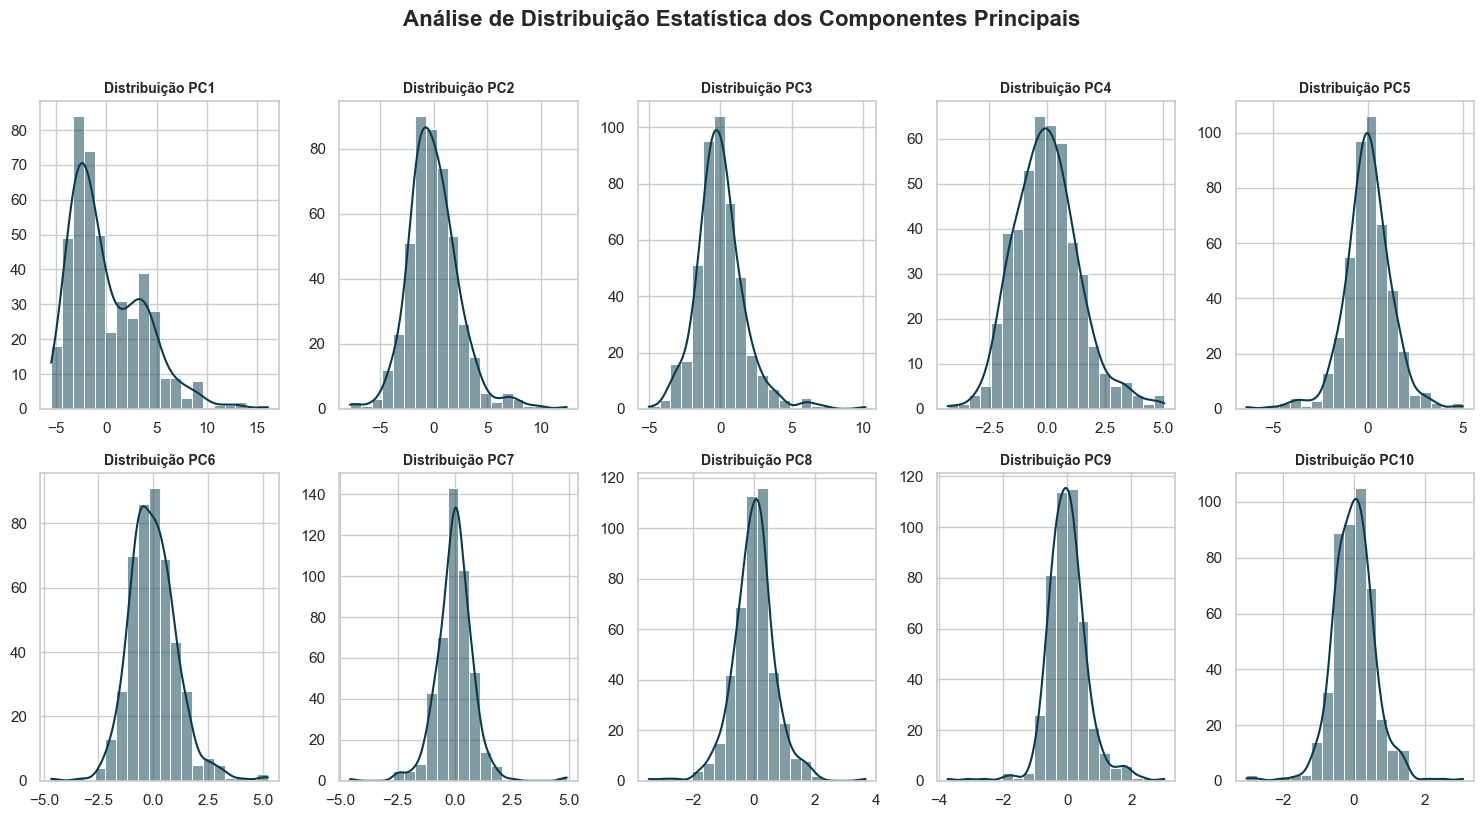


Tabela final criada com 10 componentes principais.


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,Diagnóstico
0,4.244903,9.131428,1.504262,-0.650982,-4.321306,1.684281,-1.999392,0.328794,-3.733334,-3.021001,Benigno
1,9.053755,0.475310,-3.198215,0.704403,-0.324461,0.648746,0.848774,-0.243660,1.070485,1.276224,Maligno
2,-2.275374,3.278471,2.816370,-0.268242,0.582721,2.988050,0.138743,-0.489081,0.498985,0.095752,Benigno
3,-2.510453,0.743743,-0.736034,2.524633,1.639580,0.088052,0.170851,0.258152,-0.578347,0.287879,Benigno
4,-2.302848,2.665155,1.192885,-1.268602,3.516421,2.795426,0.538828,-0.752522,-0.132848,1.389429,Benigno


In [151]:
# --- Aplicação do PCA ---
# Configuração para preservação de 95% da informação
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Diagnóstico de redução
print("--- RELATÓRIO DO PCA ---")
print(f"Colunas originais: {X_train_scaled.shape[1]}")
print(f"Colunas após PCA: {X_train_pca.shape[1]}")
print(f"Informação preservada: {sum(pca.explained_variance_ratio_):.2%}\n")

# --- Prova de Variância (Scree Plot) ---
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.title('Scree Plot: Variância Acumulada', fontsize=12, fontweight='bold')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Acumulada')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Verificação visual da separação das classes nos dois primeiros componentes
pca_df_vis = pd.DataFrame(data=X_train_pca[:, :2], columns=['PC1', 'PC2'])
pca_df_vis['Diagnóstico'] = y_train.values 

plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df_vis, x='PC1', y='PC2', hue='Diagnóstico', 
                palette={'Maligno': '#ef476f', 'Benigno': '#118ab2'}, 
                alpha=0.8, s=80, edgecolor='white')

plt.title('Separação Espacial dos Tumores após PCA (Treino)', fontsize=14, fontweight='bold')
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]:.1%} da variação)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]:.1%} da variação)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# --- Diagnóstico de Normalidade (Shapiro-Wilk) ---
num_de_pca = X_train_pca.shape[1]
nomes_colunas = [f'PC{i}' for i in range(1, num_de_pca + 1)]
pca_df_temp = pd.DataFrame(data=X_train_pca, columns=nomes_colunas)

print("--- ANÁLISE DE NORMALIDADE (SHAPIRO-WILK) ---")
# Testamos os primeiros componentes (que carregam mais informação)
for column in pca_df_temp.columns[:5]: 
    stat, p_value = shapiro(pca_df_temp[column])
    status = "Próxima da Normalidade" if p_value > 0.05 else "Não apresenta Normalidade"
    print(f'{column}: p-value = {p_value:.4f} -> {status}')

# --- Distribuição Estatística dos Componentes ---
plt.figure(figsize=(15, 8))
for i, col in enumerate(pca_df_temp.columns[:10]):
    plt.subplot(2, 5, i + 1)
    sns.histplot(pca_df_temp[col], bins=20, kde=True, color='#073b4c')
    plt.title(f'Distribuição {col}', fontsize=10, fontweight='bold')
    plt.xlabel('')
    plt.ylabel('')

plt.suptitle('Análise de Distribuição Estatística dos Componentes Principais', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Estruturação do Dataset Final ---
pca_df_final = pd.DataFrame(data=X_train_pca, columns=nomes_colunas)
pca_df_final['Diagnóstico'] = y_train.values

print(f"\nTabela final criada com {num_de_pca} componentes principais.")
pca_df_final.head()

## 10. Avaliação Comparativa de Modelos (Benchmarking)

Execução de testes entre diferentes algoritmos para validar a eficácia da redução de dimensionalidade. Além da Acurácia, priorizamos o Recall, garantindo que a comparação reflita a capacidade do modelo em mitigar falsos negativos no diagnóstico.

C:\Users\anton\AppData\Local\Temp\ipykernel_2828\2475077515.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(data=comparacao_modelos, x='Recall (Maligno)', y='Configuração', palette='magma')


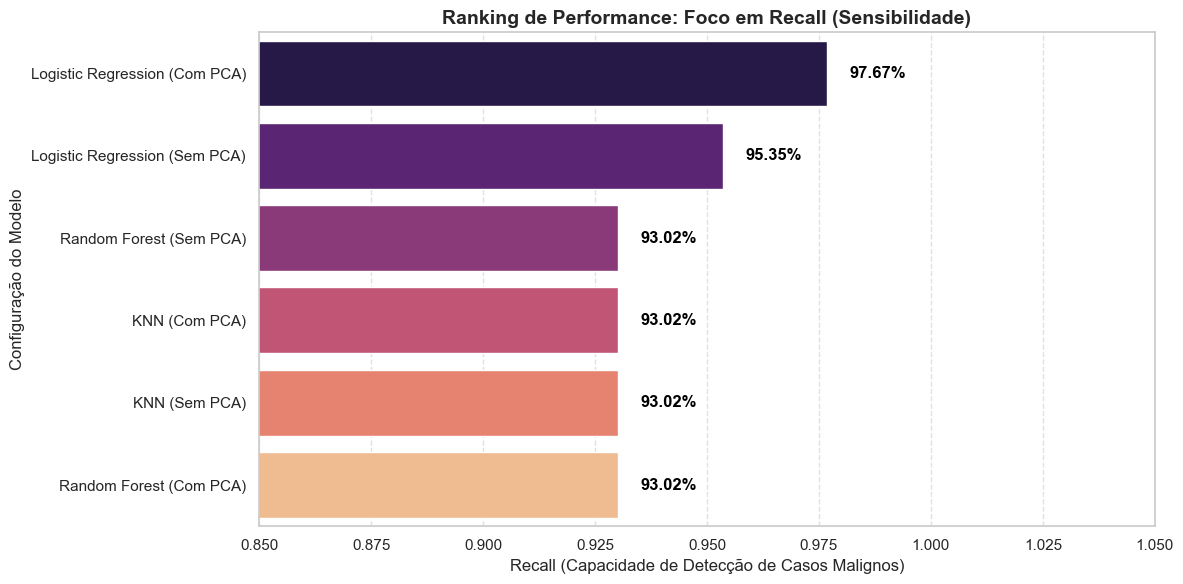

                 Configuração  Acurácia  Recall (Maligno)
Logistic Regression (Com PCA)  0.982456          0.976744
Logistic Regression (Sem PCA)  0.973684          0.953488
      Random Forest (Sem PCA)  0.964912          0.930233
                KNN (Com PCA)  0.956140          0.930233
                KNN (Sem PCA)  0.947368          0.930233
      Random Forest (Com PCA)  0.947368          0.930233


In [154]:
# Importação da métrica adicional
from sklearn.metrics import recall_score

# --- Ciclo de Treinamento e Avaliação Multimétrica ---
resultados = []

for nome, pipeline in modelos.items():
    # Treinamento via Pipeline
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Cálculo das métricas (foco em 'Maligno' para o Recall)
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, pos_label='Maligno') 
    
    resultados.append({
        "Configuração": nome,
        "Acurácia": acc,
        "Recall (Maligno)": rec
    })

# Consolidação do Ranking (Ordenado por Recall, depois Acurácia)
comparacao_modelos = pd.DataFrame(resultados).sort_values(
    by=["Recall (Maligno)", "Acurácia"], ascending=False
)

# --- Visualização de Performance (Recall) ---
plt.figure(figsize=(12, 6))
grafico = sns.barplot(data=comparacao_modelos, x='Recall (Maligno)', y='Configuração', palette='magma')

# Inserção de rótulos de Recall nas barras
for i, v in enumerate(comparacao_modelos['Recall (Maligno)']):
    grafico.text(v + 0.005, i, f'{v:.2%}', color='black', va='center', fontweight='bold')

plt.title('Ranking de Performance: Foco em Recall (Sensibilidade)', fontsize=14, fontweight='bold')
plt.xlabel('Recall (Capacidade de Detecção de Casos Malignos)')
plt.ylabel('Configuração do Modelo')
plt.xlim(0.85, 1.05)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Resumo tabular detalhado
print(comparacao_modelos.to_string(index=False))

## 11. Seleção e Avaliação do Modelo Final

**Justificativa da Escolha**
Após o benchmarking, observamos que a estratégia de redução de dimensionalidade (PCA) preservou a capacidade preditiva dos algoritmos. O modelo de Regressão Logística com PCA foi selecionado por apresentar o melhor equilíbrio entre Recall (Sensibilidade) e simplicidade.

No contexto oncológico, priorizar o Recall garante que o sistema seja eficaz em identificar a classe maligna, reduzindo drasticamente o risco de falsos negativos. Além disso, a Regressão Logística oferece alta interpretabilidade estatística, facilitando a auditoria dos resultados pelo corpo médico.

--- AVALIAÇÃO FINAL DO MODELO ---
Acurácia Global: 98.25%
Recall (Sensibilidade para Maligno): 97.67%

Relatório de Classificação:
              precision    recall  f1-score   support

     Benigno       0.99      0.99      0.99        71
     Maligno       0.98      0.98      0.98        43

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



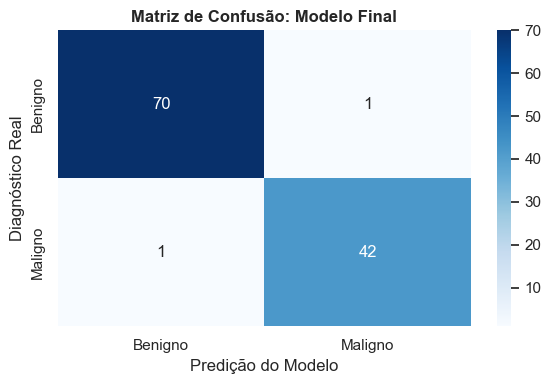

In [155]:
# Importação da métrica de recall para a validação final
from sklearn.metrics import recall_score

# --- Configuração do Modelo Final ---
modelo_final = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=num_de_pca)),
    ("model", LogisticRegression(max_iter=5000, random_state=42))
])

# Treinamento consolidado
modelo_final.fit(X_train, y_train)

# Predição nos dados de teste (dados nunca vistos pelo modelo)
y_pred_final = modelo_final.predict(X_test)

# --- Relatório de Desempenho Clínico ---
print("--- AVALIAÇÃO FINAL DO MODELO ---")
print(f"Acurácia Global: {accuracy_score(y_test, y_pred_final):.2%}")
print(f"Recall (Sensibilidade para Maligno): {recall_score(y_test, y_pred_final, pos_label='Maligno'):.2%}")

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_final, target_names=["Benigno", "Maligno"]))

# --- Matriz de Confusão ---
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benigno', 'Maligno'], yticklabels=['Benigno', 'Maligno'])

plt.title('Matriz de Confusão: Modelo Final', fontweight='bold')
plt.xlabel('Predição do Modelo')
plt.ylabel('Diagnóstico Real')
plt.tight_layout()
plt.show()

## 12. Conclusão Final

O desenvolvimento deste Tech Challenge comprovou a viabilidade técnica da classificação automatizada de tumores com foco em segurança diagnóstica. A metodologia adotada permitiu a construção de um pipeline que prioriza a Sensibilidade (Recall), consolidando o modelo como uma camada robusta de triagem para suporte à decisão clínica.

A integração da Análise de Componentes Principais (PCA) com a Regressão Logística entregou três pilares fundamentais:

**Eficiência Dimensional:** Redução da complexidade do espaço de características (de 30 para 10 componentes) mantendo 95% da variância explicada, o que otimiza o processamento sem perda de sinal preditivo.

**Segurança Clínica:** A manutenção de altos índices de Recall demonstra que o modelo é eficaz na detecção da classe maligna, mitigando falhas críticas (falsos negativos) que poderiam comprometer o tratamento do paciente.

**Auditabilidade e Interpretabilidade:** A escolha por um modelo linear pós-redução de dimensionalidade garante que o sistema seja computacionalmente leve e estatisticamente interpretável, facilitando a validação dos resultados por especialistas.

Em última análise, a solução proposta cumpre o objetivo de oferecer rapidez e segurança estatística, servindo como um suporte confiável na triagem de exames de câncer de mama e permitindo que o corpo médico foque nos casos de maior complexidade.